In [1]:
# Standard library + third-party imports
import logging
import math
from functools import cached_property
from textwrap import dedent

import numpy as np
import numpy.random as rnd
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx

# Show INFO-level log messages from GetMatricesSCA (e.g. ghost-level warnings,
# export paths). Set to DEBUG if you want per-gamma parse output.
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")

In [3]:
# Import custom functions and classes
from GetMatricesSCA import (
    MakeLevelsAndVertices,
    GetGammaObjects,
    GetGammaEnergies,
    GetSingles,
    GetCoincidences,
    GetAdjacency,
    Print_Level_Scheme,
    export_matrices,
)
from NuclearObjects import LSGraph, Gamma, Level, LevelScheme, TransitionScheme

dataFile = "Ta182_beta.gam"
# dataFile = "Am241.gam"

Glevel = MakeLevelsAndVertices(dataFile)
gammas = GetGammaObjects()
Print_Level_Scheme()

Level: 0.0
Level: 1289.149
  Gamma: 31.7377 keV  BR: 0.0141  Final state: 1257.412
  Gamma: 67.7497 keV  BR: 0.6923  Final state: 1221.4
  Gamma: 959.73 keV  BR: 0.0056  Final state: 329.4268
  Gamma: 1189.04 keV  BR: 0.2659  Final state: 100.1059
  Gamma: 1289.145 keV  BR: 0.0221  Final state: 0.0
Level: 1373.83
  Gamma: 42.7148 keV  BR: 0.0233  Final state: 1331.115
  Gamma: 84.68024 keV  BR: 0.2307  Final state: 1289.149
  Gamma: 116.4179 keV  BR: 0.0386  Final state: 1257.412
  Gamma: 152.42991 keV  BR: 0.6100  Final state: 1221.4
  Gamma: 1044.42 keV  BR: 0.0208  Final state: 329.4268
  Gamma: 1273.719 keV  BR: 0.0574  Final state: 100.1059
  Gamma: 1373.824 keV  BR: 0.0193  Final state: 0.0
Level: 1487.501
  Gamma: 44.66 keV  BR: 0.0047  Final state: 1442.836
  Gamma: 113.6717 keV  BR: 0.2924  Final state: 1373.83
  Gamma: 156.3864 keV  BR: 0.4174  Final state: 1331.115
  Gamma: 198.35187 keV  BR: 0.2289  Final state: 1289.149
  Gamma: 1158.1 keV  BR: 0.0452  Final state: 329.426

In [4]:
# Build the three matrices. nc = normalization / count scaling factor.
nc = 10000

S = GetSingles(nc)                  # list[float], length = N_gammas
C = GetCoincidences(Glevel, nc)     # np.ndarray, shape (N, N) — symmetric
w = GetAdjacency()                  # np.ndarray, shape (N, N) — branching ratios

print(f"Number of gamma-ray transitions: {len(S)}")
print(f"Coincidence matrix C shape:      {C.shape}")
print(f"Adjacency matrix  w shape:       {w.shape}")
print(f"C is symmetric:                   {np.allclose(C, C.T)}")

Computing coincidences: 100%|█████████████████████████████████████████████████████| 14/14 [00:00<00:00, 3497.96level/s]

Number of gamma-ray transitions: 44
Coincidence matrix C shape:      (44, 44)
Adjacency matrix  w shape:       (44, 44)
C is symmetric:                   True


In [5]:
# Optional: dump S, C, A to labelled CSVs (rows/cols are gamma energies in keV).
# Uncomment to write to ./matrices_out/.
# export_matrices(S, C, w, output_dir="matrices_out")

In [6]:
TS = TransitionScheme()                      # Initialize transition-centric scheme
TS.build_from_adjacency_matrix(w, 0, gammas) # Build TS from A matrix
# Threshold is the smallest matrix element considered a real coincidence.

{31.7377: [121.5, 928.0, 1157.302, 1257.407], 42.7148: [1001.7, 1231.004], 44.66: [1113.41, 1342.73], 65.72215: [44.66, 113.6717, 156.3864, 198.35187, 1158.1, 1387.39], 67.7497: [891.7, 1121.29, 1221.395], 84.68024: [31.7377, 67.7497, 959.73, 1189.04, 1289.145], 100.10595: [], 110.393: [1113.41, 1342.73], 113.6717: [42.7148, 84.68024, 116.4179, 152.42991, 1044.42, 1273.719, 1373.824], 116.4179: [121.5, 928.0, 1157.302, 1257.407], 121.5: [1035.7], 152.42991: [891.7, 1121.29, 1221.395], 156.3864: [1001.7, 1231.004], 179.39381: [42.7148, 84.68024, 116.4179, 152.42991, 1044.42, 1273.719, 1373.824], 198.35187: [31.7377, 67.7497, 959.73, 1189.04, 1289.145], 222.1085: [1001.7, 1231.004], 229.3207: [100.10595], 264.074: [31.7377, 67.7497, 959.73, 1189.04, 1289.145], 351.02: [229.3207], 829.9: [351.02], 891.7: [229.3207], 928.0: [229.3207], 959.73: [229.3207], 1001.7: [229.3207], 1035.7: [100.10595], 1044.42: [229.3207], 1113.41: [229.3207], 1121.29: [100.10595], 1135.9: [], 1157.302: [100.1059

In [7]:
for bn in TS.branchNodes:      # branch nodes are followed by adjacent transitions
    for ln in TS.leafNodes:    # leaf nodes have no outgoing transitions
        TS.find_all_paths(bn, ln)
print(f"Total cascade paths found: {len(TS.allPaths)}")

Total cascade paths found: 159


In [8]:
LS = LevelScheme()                  # Initialize level-centric scheme
LS.map_from_transition_space(TS)    # Map TS to level-space with minimal assumptions
LS.connect_nodes_with_edges()       # Add edges for gamma-ray transitions
LS.delete_edges_and_nodes()         # Remove redundant edges/nodes

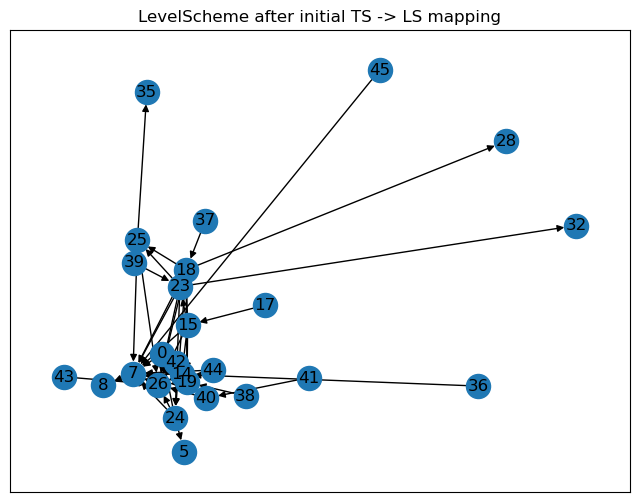

Node #0
  Incoming Gammas:  [121.5]
  Outgoing Gammas:  [1035.7]
Node #5
  Incoming Gammas:  [1257.407]
  Outgoing Gammas:  []
Node #7
  Incoming Gammas:  [229.3207, 1035.7, 1273.719, 1189.04, 1121.29, 1387.39, 1342.73, 1231.004, 1157.302, 1410.13, 1453.12]
  Outgoing Gammas:  [100.10595]
Node #8
  Incoming Gammas:  [100.10595]
  Outgoing Gammas:  []
Node #14
  Incoming Gammas:  [44.66, 110.393]
  Outgoing Gammas:  [1113.41, 1342.73]
Node #15
  Incoming Gammas:  [65.72215]
  Outgoing Gammas:  [44.66, 113.6717, 156.3864, 198.35187, 1158.1, 1387.39]
Node #17
  Incoming Gammas:  []
  Outgoing Gammas:  [65.72215]
Node #18
  Incoming Gammas:  [113.6717, 179.39381]
  Outgoing Gammas:  [42.7148, 84.68024, 116.4179, 152.42991, 1044.42, 1273.719, 1373.824]
Node #19
  Incoming Gammas:  [156.3864, 42.7148, 222.1085]
  Outgoing Gammas:  [1001.7, 1231.004]
Node #23
  Incoming Gammas:  [84.68024, 198.35187, 264.074]
  Outgoing Gammas:  [31.7377, 67.7497, 959.73, 1189.04, 1289.145]
Node #24
  Incomin

In [9]:
plt.figure(figsize=(8, 6))
nx.draw_networkx(LS.g)
plt.title("LevelScheme after initial TS -> LS mapping")
plt.show()

for lvl in LS.levels:
    print(f"Node #{lvl}")
    print("  Incoming Gammas: ", [g.gE for g in LS.levels[lvl].inGammas])
    print("  Outgoing Gammas: ", [g.gE for g in LS.levels[lvl].outGammas])

print("Redundant nodes:", [lvl for lvl in LS.levels if lvl in LS.redundantNodes])

In [10]:
LS.build_gamma_cascades(TS)   # Dict of all gamma-ray pathways between two nodes
LS.compute_path_lengths()     # Path lengths = sum of gamma energies along cascade

In [11]:
print(LS.pathLengths)
LS.merge_redundant_leaves(energy_threshold=1)   # Tolerance in keV
LS.delete_edges_and_nodes()

{(23, 8): 1289.096892857143, (23, 5): 1289.1446999999998, (18, 8): 1373.78465, (15, 8): 1487.4643979310345, (17, 8): 1553.186547931034, (17, 35): 1553.2187566666664, (17, 5): 1553.2187533333333, (17, 32): 1553.219055, (17, 28): 1553.21785, (23, 35): 1289.1447, (18, 35): 1373.824925, (18, 5): 1373.82492, (18, 32): 1373.82524, (36, 8): 1553.2293000000002, (15, 35): 1487.4966066666666, (15, 5): 1487.496603333333, (15, 32): 1487.496905, (15, 28): 1487.4957000000002, (24, 8): 1257.3801833333332, (37, 8): 1553.1784599999996, (37, 35): 1553.218735, (37, 5): 1553.21873, (37, 32): 1553.21905, (37, 28): 1553.21781, (38, 8): 1553.2268, (26, 8): 329.42665, (39, 8): 1553.170892857143, (39, 35): 1553.2187, (39, 5): 1553.2187, (39, 32): 1553.219, (40, 8): 680.44665, (41, 8): 1510.34665, (25, 8): 1221.2613000000001, (19, 8): 1331.1183, (0, 8): 1135.80595, (14, 8): 1442.8363000000002, (42, 8): 1510.2766499999998, (43, 8): 1553.0266499999998, (44, 8): 1510.2359500000002, (45, 8): 1553.22595}
New edge:  

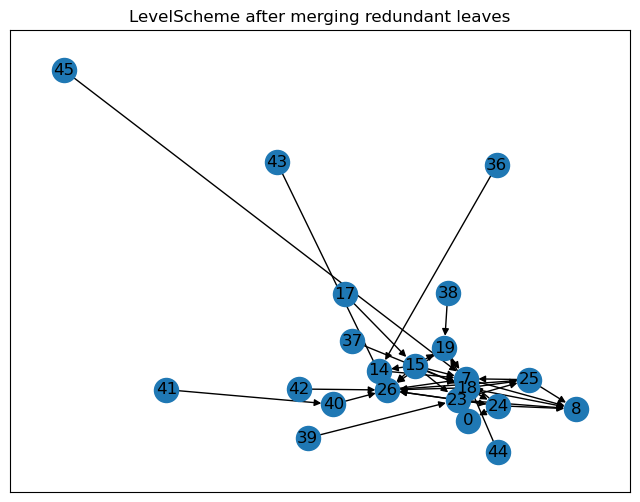

In [12]:
plt.figure(figsize=(8, 6))
nx.draw_networkx(LS.g)
plt.title("LevelScheme after merging redundant leaves")
plt.show()

In [13]:
LS.find_leaf_nodes()
LS.leaf_node_deexcitation_energies()
LS.leaf_node_incoming_intensity(gammas, S)

Maximum energy lost when populating leaf nodes:  {(45, 8): 1553.2293000000002}
Total number of gammas going into each leaf node:  {8: 1263770.0}


In [14]:
# Node corresponding to the ground state; currently user-specified.
# Adjust if you switch data files.
LS.compute_level_energies(gsNode=8)

In [15]:
for node in LS.g.nodes:
    print(f"Node: {node}   Energy: {LS.g.nodes[node]['energy']}")
    print("  Incoming gammas:", [g.gE for g in LS.levels[node].inGammas])
    print("  Outgoing gammas:", [g.gE for g in LS.levels[node].outGammas])
    print("-" * 40)


Node: 0   Energy: 1135.90635
  Incoming gammas: [121.5]
  Outgoing gammas: [1035.7]
----------------------------------------
Node: 7   Energy: 100.10595
  Incoming gammas: [229.3207, 1035.7, 1273.719, 1189.04, 1121.29, 1387.39, 1342.73, 1231.004, 1157.302, 1410.13, 1453.12]
  Outgoing gammas: [100.10595]
----------------------------------------
Node: 8   Energy: 0.0
  Incoming gammas: [100.10595, 1257.407, 1221.395, 1289.145, 1373.824]
  Outgoing gammas: []
----------------------------------------
Node: 14   Energy: 1442.8359500000001
  Incoming gammas: [44.66, 110.393]
  Outgoing gammas: [1113.41, 1342.73]
----------------------------------------
Node: 15   Energy: 1487.49595
  Incoming gammas: [65.72215]
  Outgoing gammas: [44.66, 113.6717, 156.3864, 198.35187, 1158.1, 1387.39]
----------------------------------------
Node: 17   Energy: 1553.2181
  Incoming gammas: []
  Outgoing gammas: [65.72215]
----------------------------------------
Node: 18   Energy: 1373.82425
  Incoming gamma

In [16]:
LS.merge_redundant_roots(energy_threshold=1)
LS.delete_edges_and_nodes()


In [17]:
for edge in LS.g.edges:
    print(
        f"Edge: {edge}  "
        f"Gamma energy: {LS.g.edges[edge]['energy']}  "
        f"Branching ratio: {LS.g.edges[edge]['weight']:.4f}"
    )


Edge: (0, 7)  Gamma energy: 1035.7  Branching ratio: 1.0000
Edge: (7, 8)  Gamma energy: 100.10595  Branching ratio: 1.0000
Edge: (14, 7)  Gamma energy: 1342.73  Branching ratio: 0.3658
Edge: (14, 26)  Gamma energy: 1113.41  Branching ratio: 0.6342
Edge: (15, 7)  Gamma energy: 1387.39  Branching ratio: 0.0114
Edge: (15, 14)  Gamma energy: 44.66  Branching ratio: 0.0047
Edge: (15, 18)  Gamma energy: 113.6717  Branching ratio: 0.2924
Edge: (15, 19)  Gamma energy: 156.3864  Branching ratio: 0.4174
Edge: (15, 23)  Gamma energy: 198.35187  Branching ratio: 0.2289
Edge: (15, 26)  Gamma energy: 1158.1  Branching ratio: 0.0452
Edge: (17, 15)  Gamma energy: 65.72215  Branching ratio: 0.1704
Edge: (18, 7)  Gamma energy: 1273.719  Branching ratio: 0.0574
Edge: (18, 19)  Gamma energy: 42.7148  Branching ratio: 0.0233
Edge: (18, 23)  Gamma energy: 84.68024  Branching ratio: 0.2307
Edge: (18, 24)  Gamma energy: 116.4179  Branching ratio: 0.0386
Edge: (18, 25)  Gamma energy: 152.42991  Branching ratio

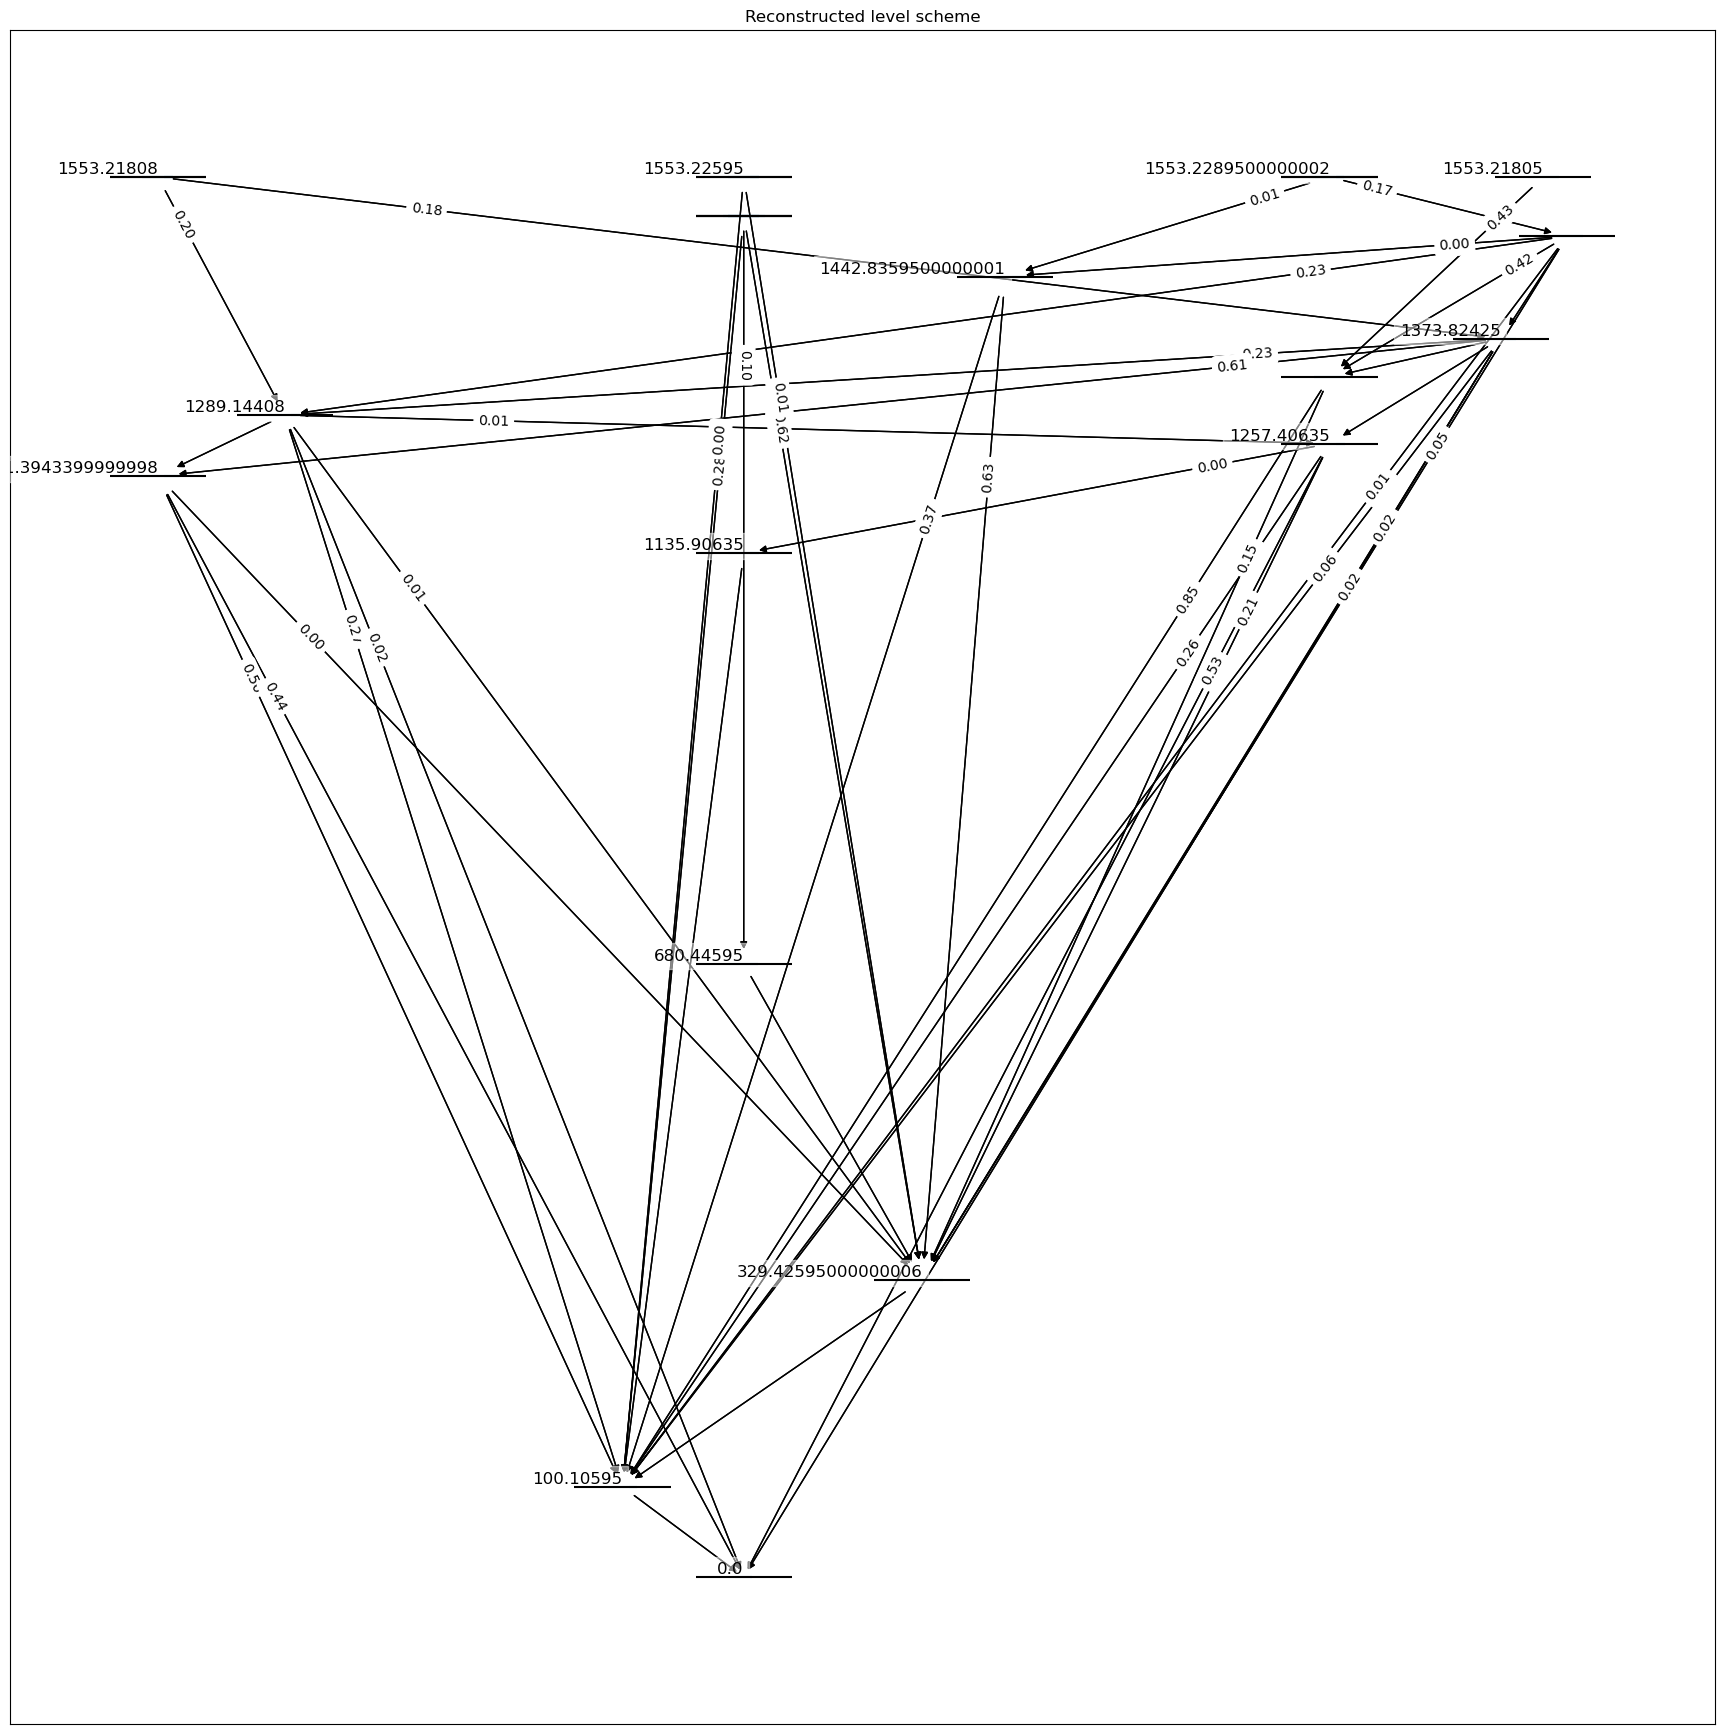

In [18]:
from Plotting import draw_level_scheme, draw_transition_scheme

num_levels = len(LS.levels)
fig = plt.figure(figsize=(max(num_levels, 6), max(num_levels, 6)))
ax = plt.gca()
draw_level_scheme(LS, ax, branch=True)
plt.title("Reconstructed level scheme")
plt.show()


In [19]:
LS.leafNodes

[8]